# Exploratory Data Analysis

## 0. Import Packages

In [96]:
#basic
import numpy as np
import pandas as pd
import os
import math

#plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
import shap
from scipy.spatial import ConvexHull
import statsmodels.formula.api as smf

#model training
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler


#optimizer
from skopt import BayesSearchCV
from skopt.space import Real, Integer

#regressors
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## 1. Import Dataset

In [97]:
#get user name
user_name = os.getlogin()
print(user_name)

Yushu gong


In [98]:
#reading the local csv
if user_name == 'Yushu gong':
    df = pd.read_csv("C:\\Users\\Yushu gong\\Desktop\\Albert School\\ML-SL\\Final-Project\\company_esg_financial_dataset.csv")
else:
    df = pd.read_csv(r"/Users/vivianhung/Documents/git_project/Machine-Learning-Project/data/company_esg_financial_dataset.csv")

In [99]:
df.head(10)

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8
5,1,Company_1,Retail,Latin America,2020,567.5,6.0,384.1,2.3,55.7,65.1,28.5,73.5,42245.4,21122.7,84490.9
6,1,Company_1,Retail,Latin America,2021,604.2,5.2,479.3,6.5,55.6,66.8,25.5,74.6,44263.8,22131.9,88527.7
7,1,Company_1,Retail,Latin America,2022,593.2,4.2,248.4,-1.8,57.7,69.0,27.1,76.9,42536.3,21268.2,85072.6
8,1,Company_1,Retail,Latin America,2023,636.7,5.3,373.9,7.3,57.8,68.3,27.0,78.1,45956.3,22978.2,91912.6
9,1,Company_1,Retail,Latin America,2024,687.0,4.6,460.1,7.9,58.5,68.9,29.9,76.8,49289.1,24644.5,98578.1


In [100]:
df.columns

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [102]:
# the data set missing the one year of growthrate data
df_missing = df[df.isnull().any(axis=1)]
print(df_missing.shape)
df_missing.head(5)

(1000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
11,2,Company_2,Retail,Asia,2015,2934.8,-2.9,1803.1,NaN,59.9,61.1,48.6,69.8,226554.2,113277.1,453108.3
22,3,Company_3,Transportation,Latin America,2015,259.7,5.9,140.2,NaN,25.5,3.3,41.6,31.5,183314.5,30552.4,611048.2
33,4,Company_4,Technology,Africa,2015,5036.7,21.2,23192.4,NaN,54.2,97.6,46.2,18.9,130146.6,78087.9,260293.2
44,5,Company_5,Finance,Middle East,2015,2720.9,16.1,3884.5,NaN,43.5,71.9,19.1,39.4,37894.7,18947.3,94736.7


In [103]:
#checking the unique value and time deminsion
print('The dataset contains', df['Year'].nunique(), 'years data')
print('The numbers of company in this dataset is', df['CompanyID'].nunique())

The dataset contains 11 years data
The numbers of company in this dataset is 1000


In [104]:
#for plotting and training we take year 2016-2025 for the complete set of data be used
df_all = df.sort_values(by=['CompanyID', 'Year']).copy()
print("Before dropping the 2015's, we have the df shape as", df_all.shape)

df_final = df_all.dropna().reset_index(drop=True)
print("After dropping, we got the df shape as", df_final.shape)

Before dropping the 2015's, we have the df shape as (11000, 16)
After dropping, we got the df shape as (10000, 16)


## 2. EDA

### 2.1 ESG data general view

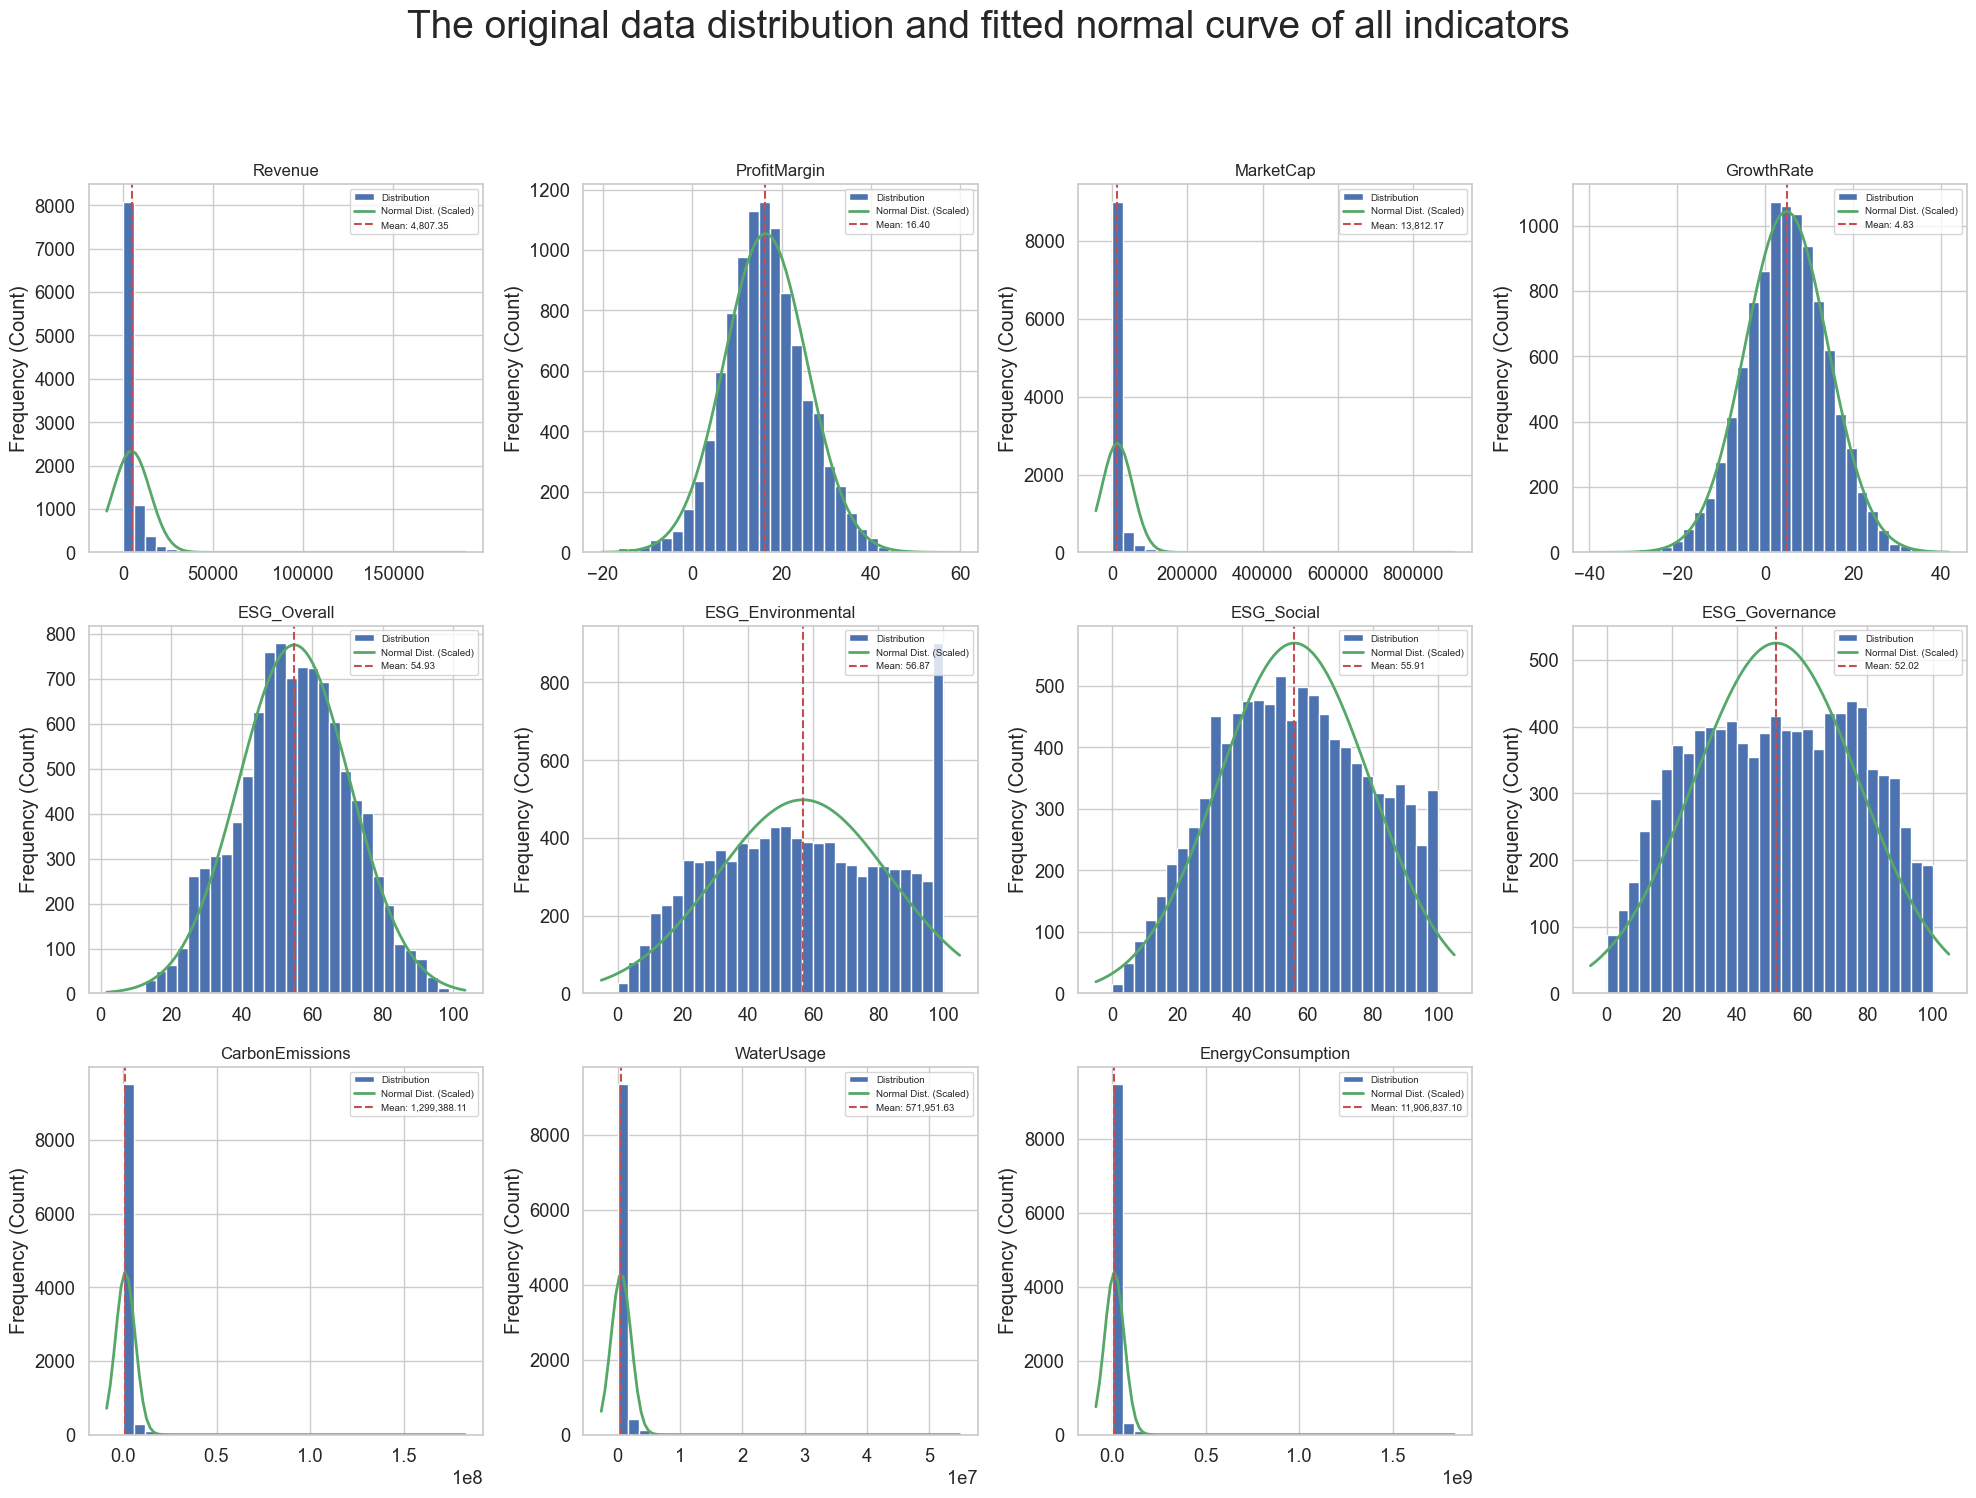

In [130]:
# List of numerical columns
numeric_cols = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
    'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]
plots_per_row = 4
num_bins = 30 # 定义 bin 数量

# --- 关键修正：计算总行数，创建单个大的 figure/axes 数组 ---
total_plots = len(numeric_cols)
n_rows = math.ceil(total_plots / plots_per_row)

# 创建一个包含所有子图的 Figure 对象
fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(20, n_rows * 5))
axes = axes.flatten() # 将 axes 数组展平，方便迭代

fig.suptitle('The original data distribution and fitted normal curve of all indicators', fontsize=28, y=1.00)

# Loop through all columns sequentially
for i, col in enumerate(numeric_cols):
    ax = axes[i] 

    series = pd.to_numeric(df_final[col], errors='coerce').dropna()
    if series.empty:
        ax.set_visible(False)
        continue

    # --- 1. PLOT HISTOGRAM (Frequency/Count) ---
    counts, bin_edges, _ = ax.hist(series, bins=num_bins, label='Distribution')
    
    # --- 2. CALCULATE NORMAL DISTRIBUTION PARAMETERS & SCALING ---
    mu = series.mean()
    sigma = series.std()
    
    # Calculate scaling factor for 'Frequency (Count)' plot
    total_count = len(series)
    bin_width = bin_edges[1] - bin_edges[0]
    scaling_factor = total_count * bin_width
    
    # Generate x values for the curve
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    
    # Calculate the PDF and scale it
    p = norm.pdf(x, mu, sigma)
    scaled_p = p * scaling_factor
    
    # --- 3. PLOT THE NORMAL DISTRIBUTION CURVE ---
    ax.plot(x, scaled_p, 'g-', linewidth=2, label='Normal Dist. (Scaled)')
    # --- 4. PLOT MEAN LINE ---
    ax.axvline(mu, color='r', linestyle='--', linewidth=1.5, label=f'Mean: {mu:,.2f}')
    
    # Set titles and labels
    ax.set_title(f"{col}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency (Count)")
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines, labels , loc='upper right', fontsize=7)
# --- 隐藏多余的子图 ---
for j in range(total_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

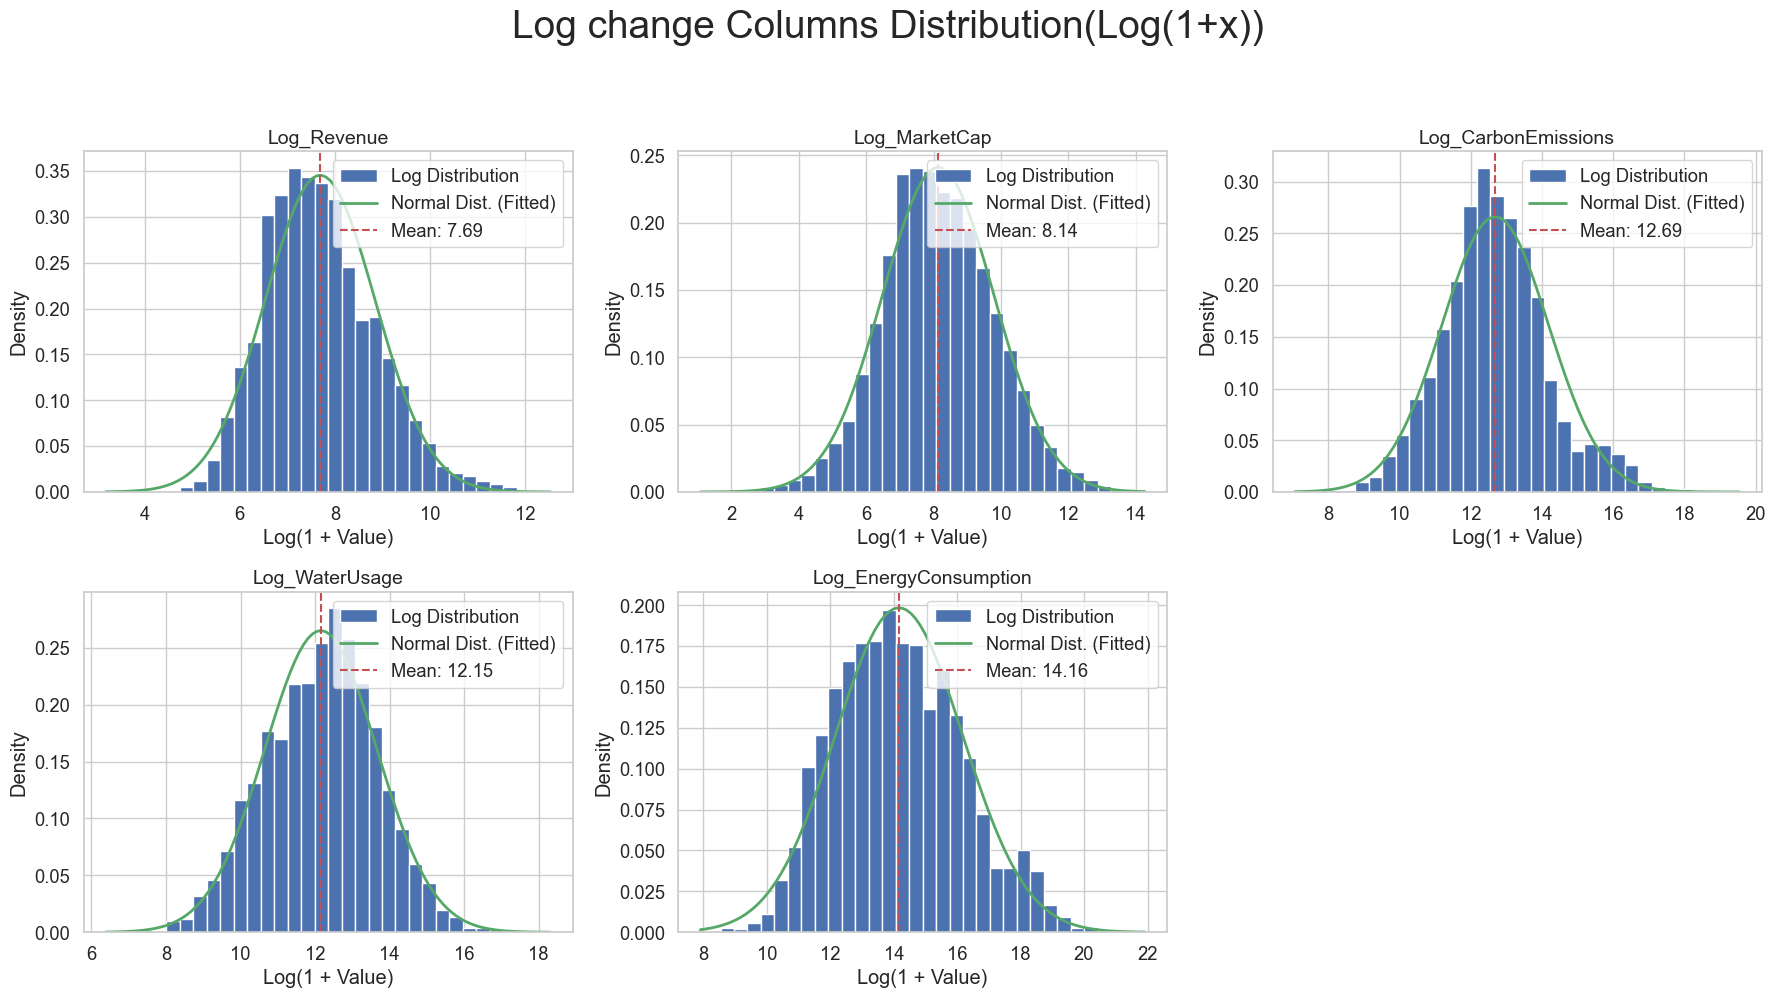

In [133]:
# 待分析的指标
cols_to_log = ['Revenue', 'MarketCap', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

# 创建一个新的 DataFrame 来存储对数转换后的数据
df_log = pd.DataFrame()
for col in cols_to_log:
    # 使用 np.log1p (log(1+x)) 进行对数转换
    df_log[f'Log_{col}'] = np.log1p(df_final[col])

# --- 2. 绘图：展示对数转换后的分布 ---

# 设定图表风格
sns.set_style("whitegrid")
# 创建 2 行 3 列的子图布局 (5 个指标)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # 将 axes 展平，方便循环

fig.suptitle('Log change Columns Distribution(Log(1+x))', fontsize=28, y=1.00)

# 循环绘制每个 Log 转换后的指标
for i, col in enumerate(df_log.columns):
    if i >= len(axes) - 1 and len(df_log.columns) < len(axes): # 确保最后一张图空着
        axes[i].set_visible(False)
        break
    
    ax = axes[i]
    series = df_log[col].dropna()
    
    # 绘制直方图
    counts, bin_edges, _ = ax.hist(series, bins=30, density=True, label='Log Distribution')
    
    # 计算正态分布参数 (Mean and Std)
    mu = series.mean()
    sigma = series.std()
    
    # 绘制拟合的正态分布曲线
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    
    # 绘制正态分布曲线
    ax.plot(x, p, 'g-', linewidth=2, label='Normal Dist. (Fitted)')
    
    # 绘制 Mean 虚线
    ax.axvline(mu, color='r', linestyle='--', linewidth=1.5, label=f'Mean: {mu:.2f}')
    
    ax.set_title(col, fontsize=14)
    ax.set_xlabel('Log(1 + Value)')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

# 隐藏最后一个多余的子图
if len(df_log.columns) < len(axes):
    axes[-1].set_visible(False)
    
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 2.2 ESG data by year/region/industry view

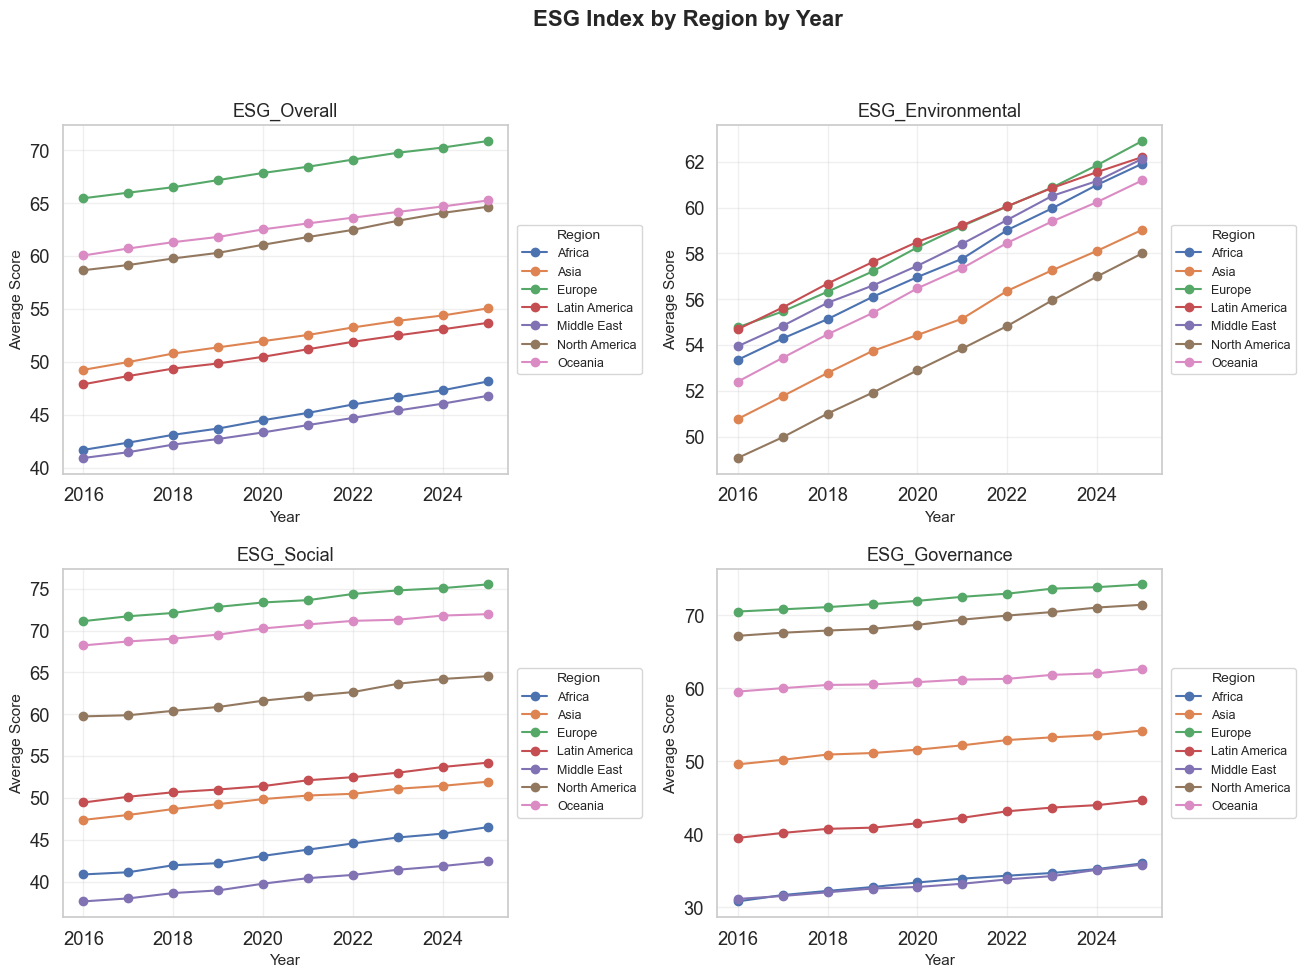

In [107]:
# ESG columns to plot
esg_columns = ['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance']

n_cols = 2 
n_rows = math.ceil(len(esg_columns) / n_cols)

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*5))
axes = axes.flatten()  # flatten for easy iteration

for i, col in enumerate(esg_columns):
    ax = axes[i]
    df_avg = df_final.groupby(['Year', 'Region'])[col].mean().reset_index()

    # Plot each region's trend
    for region in df_avg['Region'].unique():
        data = df_avg[df_avg['Region'] == region]
        ax.plot(data['Year'], data[col], marker='o', label=region)

    # Titles and labels
    ax.set_title(f'{col}', fontsize=13)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Average Score', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Legend outside each subplot on the right
    ax.legend(
        title='Region',
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        borderaxespad=0.,
        fontsize=9,
        title_fontsize=10
    )

# 隐藏多余的子图（如果有的话）
for j in range(len(esg_columns), len(axes)):
    axes[j].set_visible(False)

# Add a single main title for the entire figure
fig.suptitle('ESG Index by Region by Year', fontsize=16, fontweight='bold')

# Adjust layout to leave space for the main title and legends
plt.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()

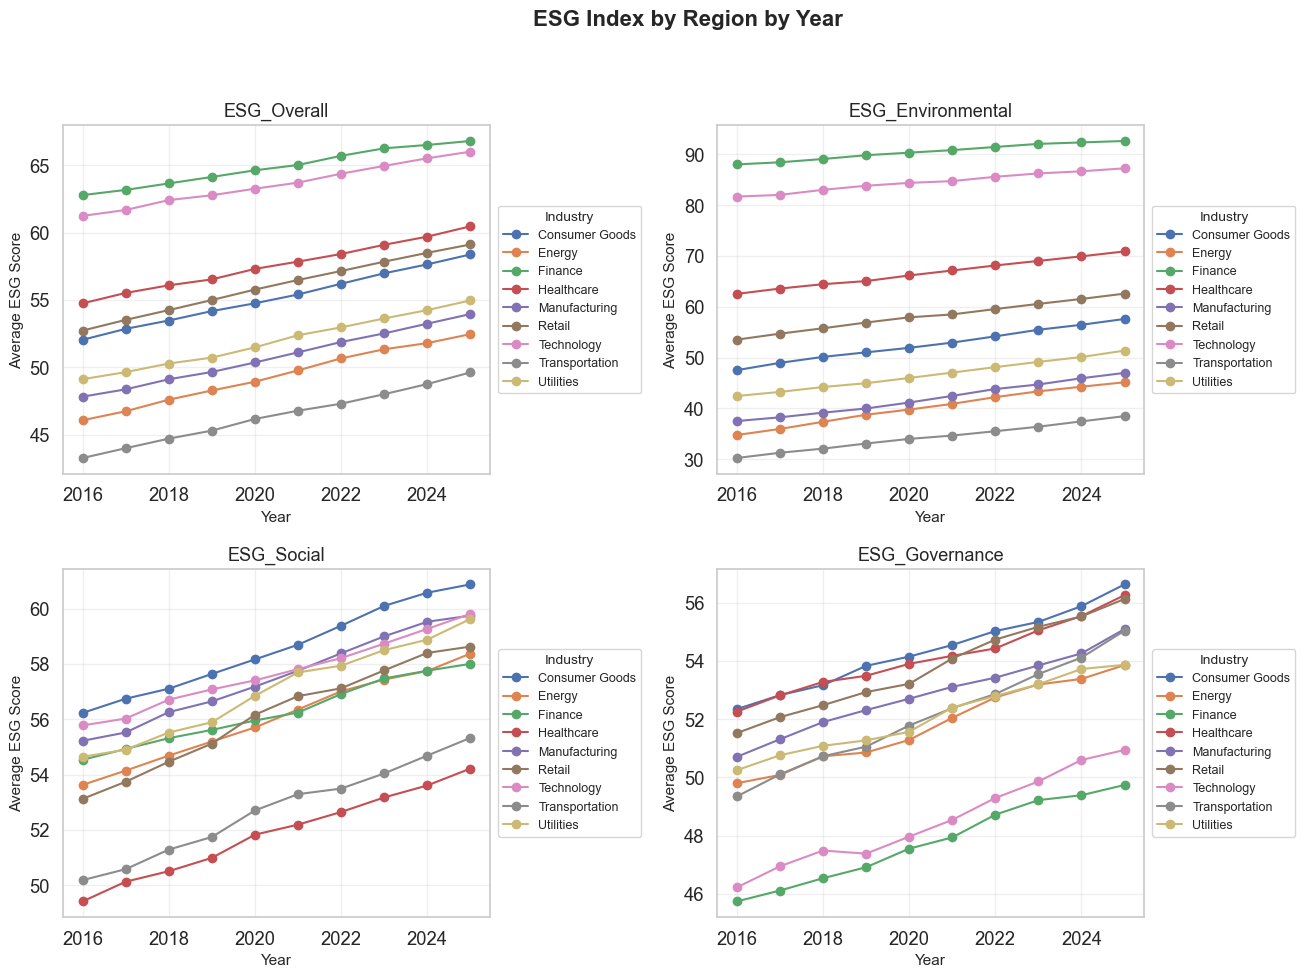

In [108]:
# ESG columns to plot
esg_columns = ['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance']

n_cols = 2 
n_rows = math.ceil(len(esg_columns) / n_cols)

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*5))
axes = axes.flatten()  # flatten for easy iteration

for i, col in enumerate(esg_columns):
    ax = axes[i]
    df_avg = df_final.groupby(['Year', 'Industry'])[col].mean().reset_index()

    # Plot each region's trend
    for region in df_avg['Industry'].unique():
        data = df_avg[df_avg['Industry'] == region]
        ax.plot(data['Year'], data[col], marker='o', label=region)

    # Titles and labels
    ax.set_title(f'{col}', fontsize=13)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Average ESG Score', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Legend outside each subplot on the right
    ax.legend(
        title='Industry',
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        borderaxespad=0.,
        fontsize=9,
        title_fontsize=10
    )

# 隐藏多余的子图（如果有的话）
for j in range(len(esg_columns), len(axes)):
    axes[j].set_visible(False)

# Add a single main title for the entire figure
fig.suptitle('ESG Index by Region by Year', fontsize=16, fontweight='bold')

# Adjust layout to leave space for the main title and legends
plt.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()


### 2.3 Distribution of Financial & ESG Metrics by Industry

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

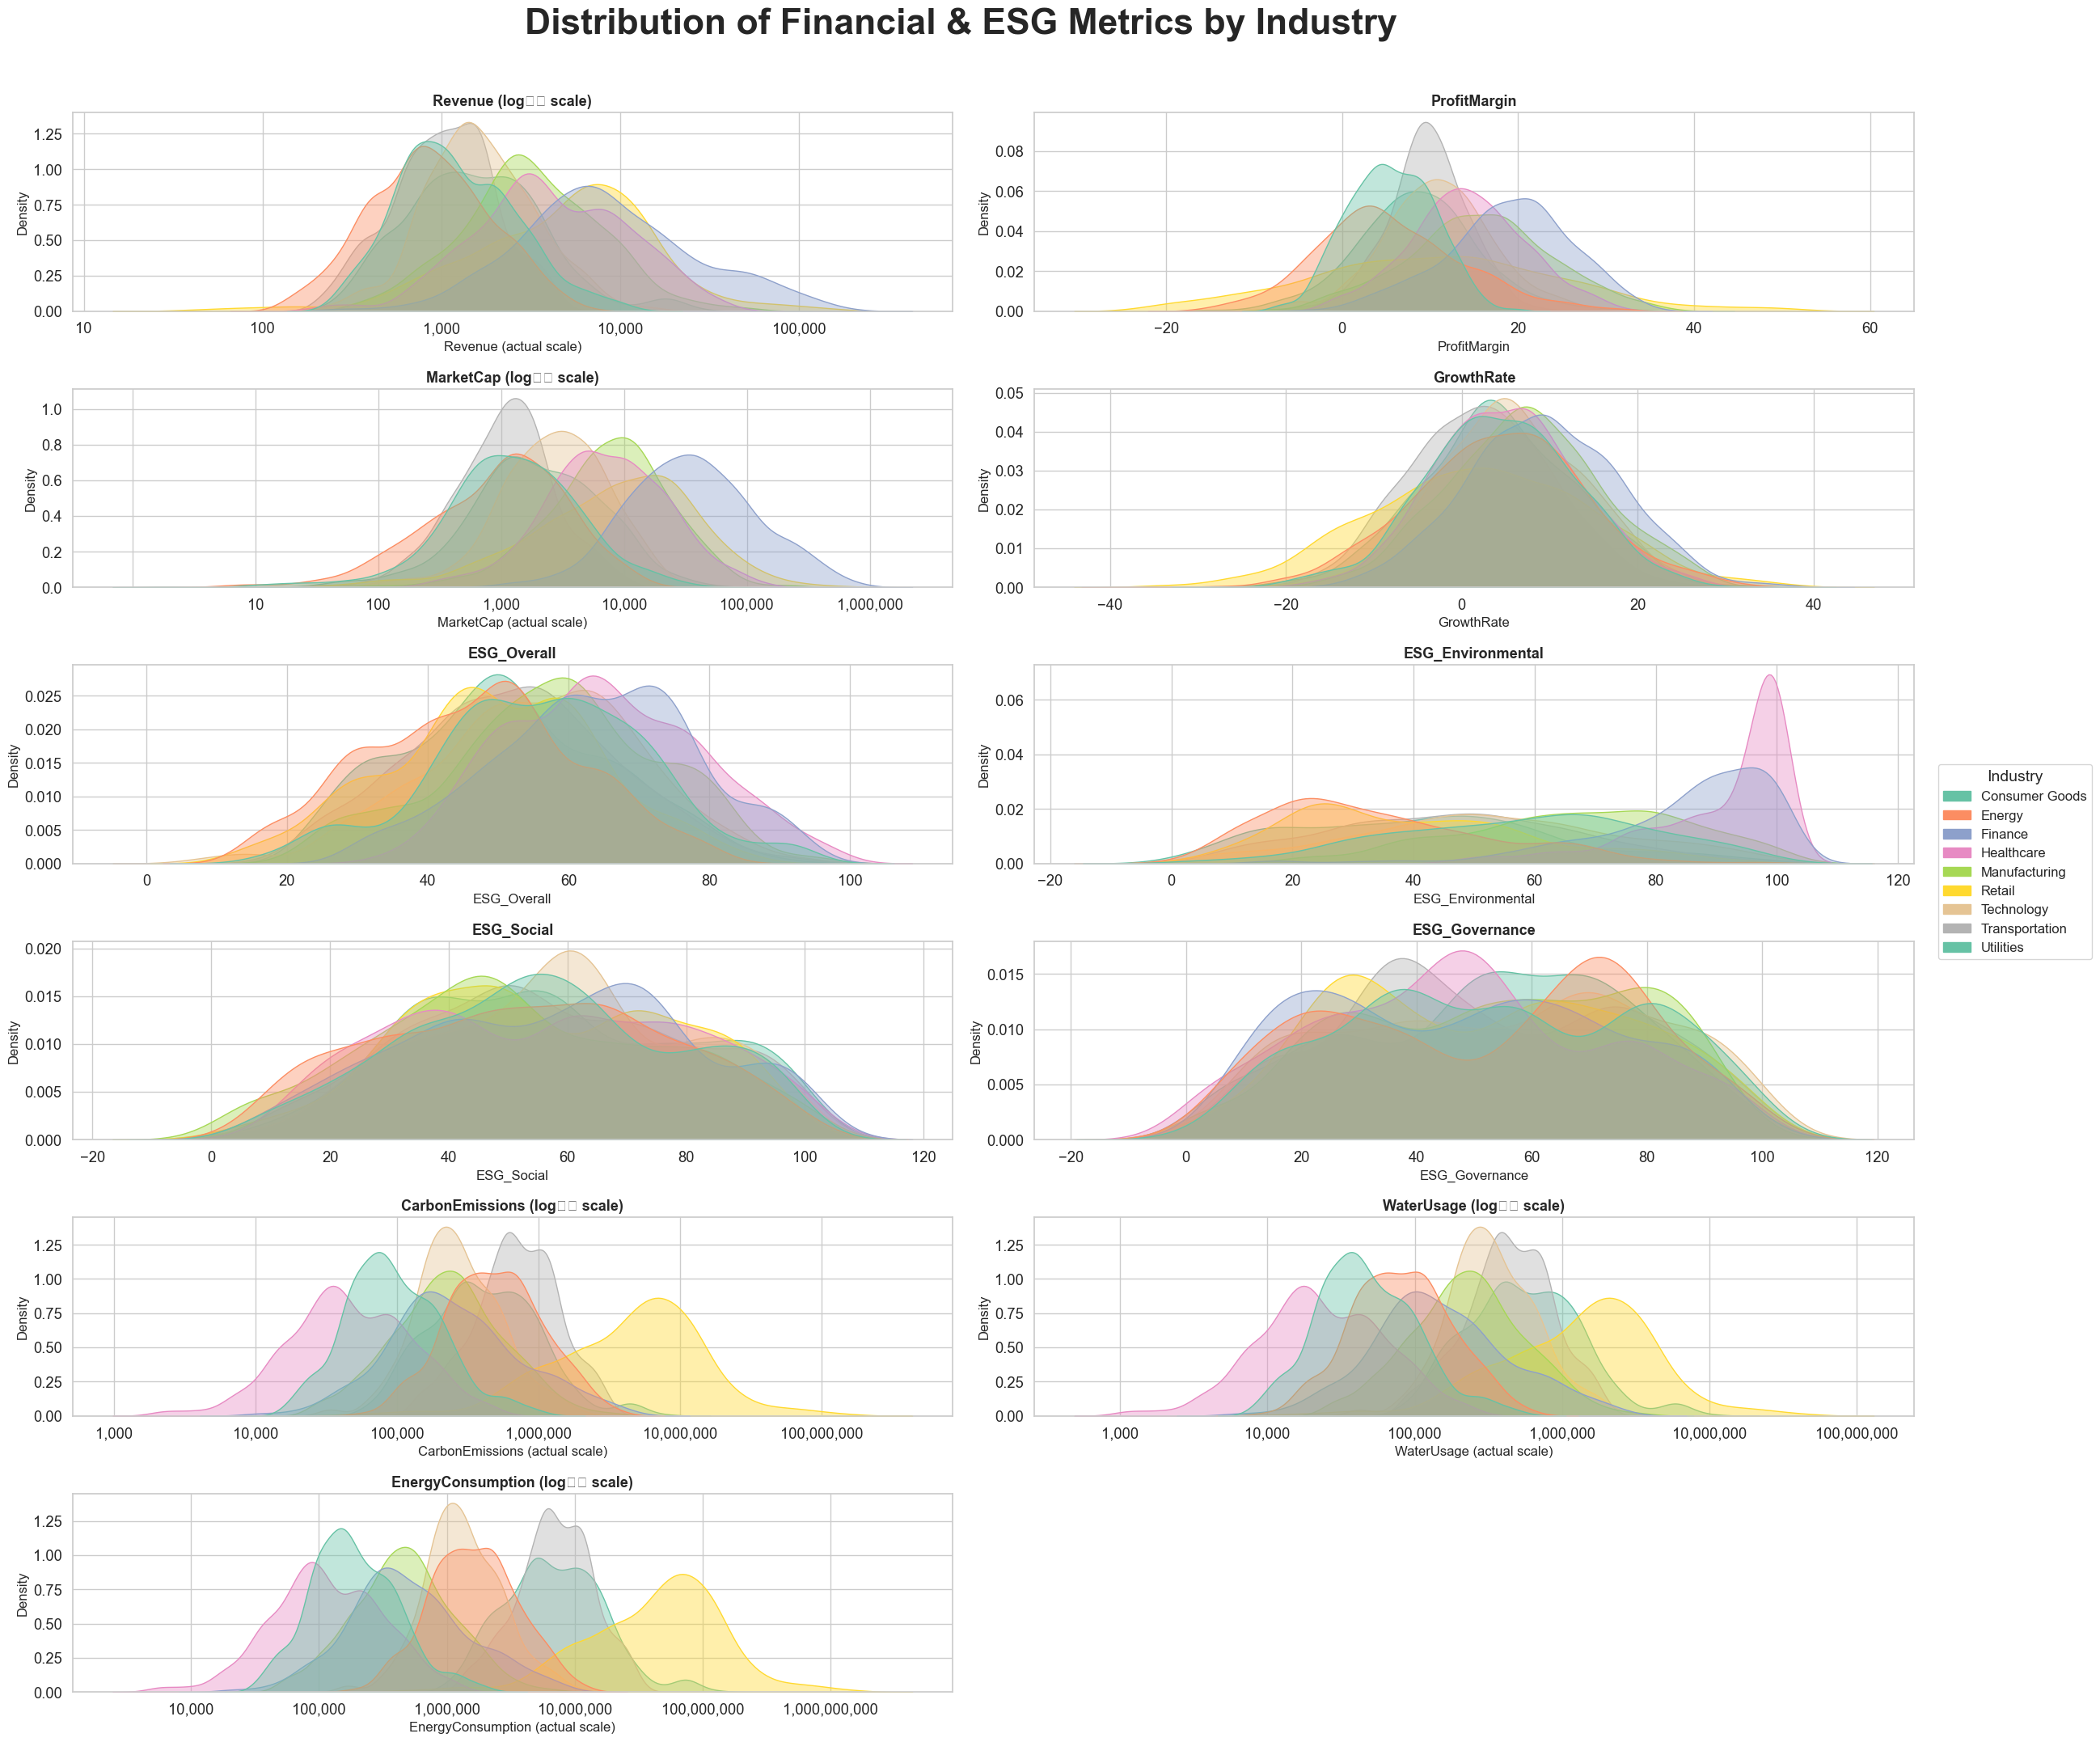

In [109]:
# Columns to visualize
cols_to_plot = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]

# Columns that should use log-scale due to wide range
wide_range_cols = ['Revenue', 'MarketCap', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

# Plot setup
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("Set2", n_colors=df_final['Industry'].nunique())

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 22))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    if col in wide_range_cols:
        df_plot = df_final.copy()
        df_plot[col] = np.log10(df_plot[col].replace(0, np.nan))

        sns.kdeplot(
            data=df_plot,
            x=col,
            hue="Industry",
            fill=True,
            common_norm=False,
            alpha=0.4,
            ax=ax,
            palette=palette,
            legend=False
        )

        ax.set_title(f"{col} (log₁₀ scale)", fontsize=13, fontweight="bold")
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
        ax.set_xlabel(f"{col} (actual scale)", fontsize=12)

    else:
        sns.kdeplot(
            data=df_final,
            x=col,
            hue="Industry",
            fill=True,
            common_norm=False,
            alpha=0.4,
            ax=ax,
            palette=palette,
            legend=False
        )

        ax.set_title(col, fontsize=13, fontweight="bold")
        ax.set_xlabel(col, fontsize=12)

    ax.set_ylabel("Density", fontsize=12)

# Remove unused axes
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# Legend
industries = sorted(df_final["Industry"].unique())
color_map = dict(zip(industries, palette))

patches = [
    mpatches.Patch(color=color_map[ind], label=ind)
    for ind in industries
]

fig.legend(
    handles=patches,
    title='Industry',
    bbox_to_anchor=(1, 0.5),
    loc='center left',
    fontsize=12,
    title_fontsize=14
)

# Layout & Title
plt.suptitle(
    "Distribution of Financial & ESG Metrics by Industry",
    fontsize=32,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 2.4 Correlation Heatmap of Financial and ESG

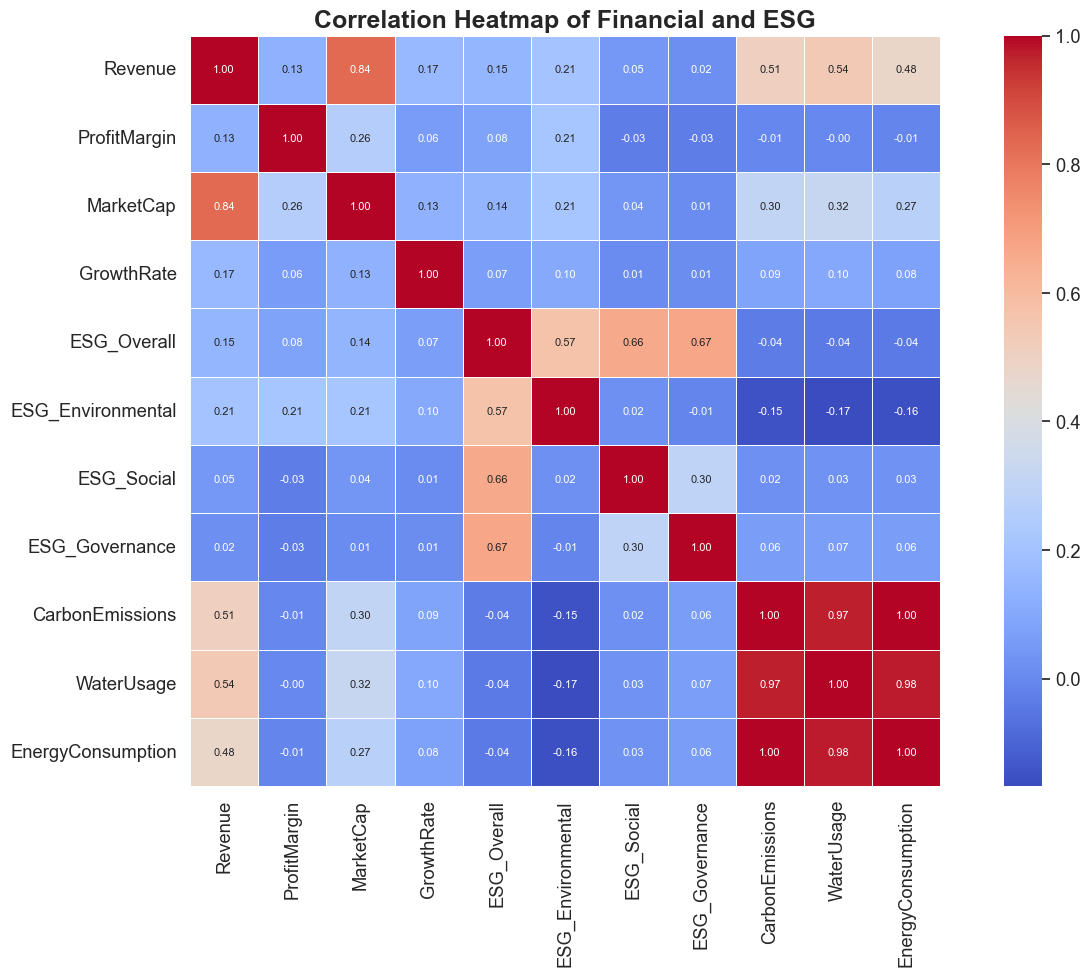

In [110]:
# Select only numeric columns that make sense for correlation
numeric_cols = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]

# Compute correlation matrix
corr = df_final[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Correlation Heatmap of Financial and ESG', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Does good ESG performance lead to (or coincide with) higher profitability?

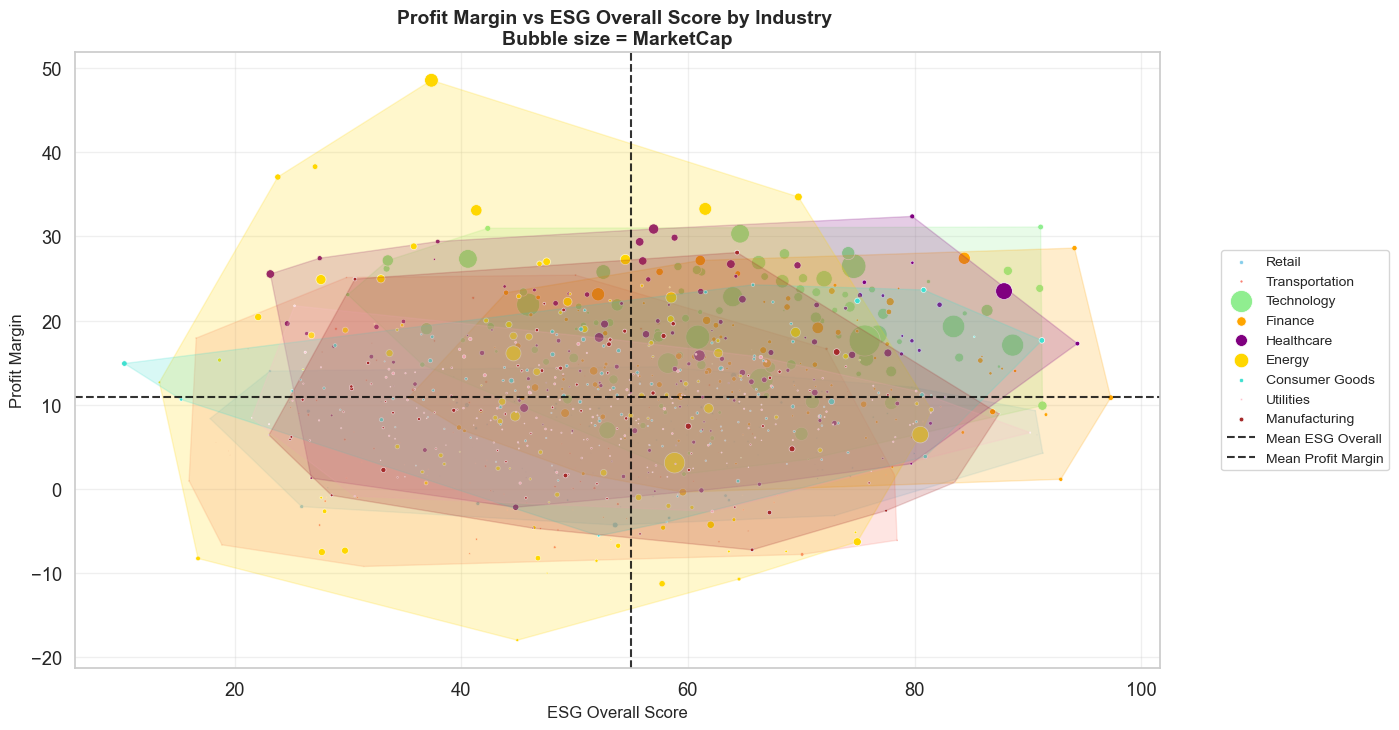

In [ ]:
plt.figure(figsize=(14, 8))

cols_to_group = ['CompanyID', 'CompanyName', 'Industry', 'Region']
cols_to_avg = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
    'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'EnergyConsumption','WaterUsage', 'CarbonEmissions'
]

df_grp_by_company = df_final.groupby(cols_to_group)[cols_to_avg].mean().reset_index()

colors = [
    'skyblue', 'salmon', 'lightgreen', 'orange', 'purple',
    'gold', 'turquoise', 'pink', 'brown'
]

size_scale = 500

def plot_hull(ax, x, y, color):
    if len(x) >= 3:
        points = np.column_stack((x, y))
        hull = ConvexHull(points)
        hull_vertices = np.append(hull.vertices, hull.vertices[0])
        ax.fill(points[hull_vertices,0], points[hull_vertices,1], color=color, alpha=0.2)

ax = plt.gca()  

for industry, color in zip(df_grp_by_company['Industry'].unique(), colors):
    data = df_grp_by_company[df_grp_by_company['Industry'] == industry]
    sizes = data['MarketCap'] / df_grp_by_company['MarketCap'].max() * size_scale
    
    ax.scatter(data['ESG_Overall'], data['ProfitMargin'],
               s=sizes, color=color, label=industry, alpha=1, edgecolors='w', linewidth=0.5)
    
    plot_hull(ax, data['ESG_Overall'].values, data['ProfitMargin'].values, color)

mean_x = df_grp_by_company['ESG_Overall'].mean()
mean_y = df_grp_by_company['ProfitMargin'].mean()
ax.axvline(mean_x, color='black', linestyle='--', alpha=0.8, label='Mean ESG Overall')
ax.axhline(mean_y, color='black', linestyle='--', alpha=0.8, label='Mean Profit Margin')

ax.set_xlabel('ESG Overall Score', fontsize=12)
ax.set_ylabel('Profit Margin', fontsize=12)
ax.set_title('Profit Margin vs ESG Overall Score by Industry \nBubble size = MarketCap', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05,0.5), loc='center left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.show()

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\2268540363.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


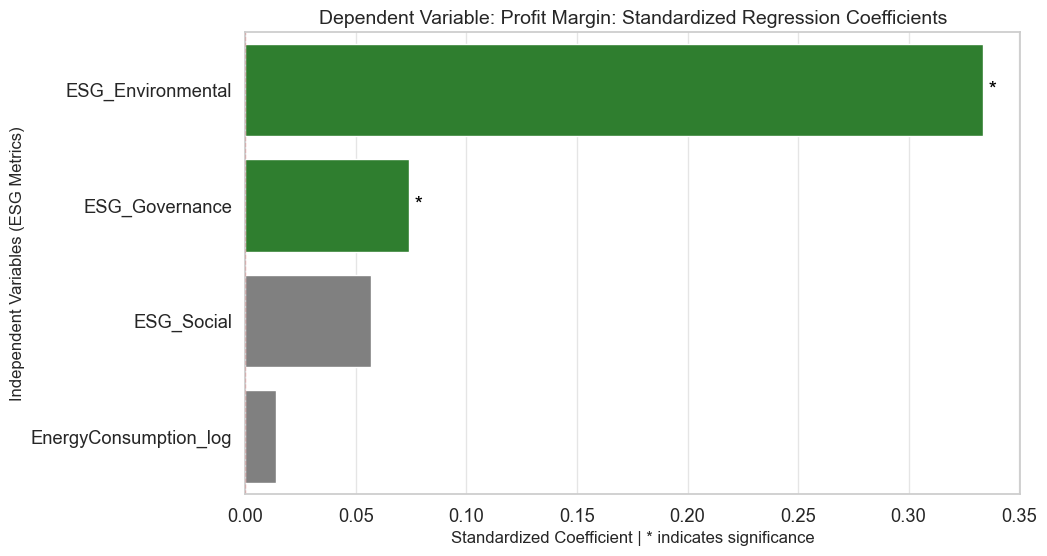

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\2268540363.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


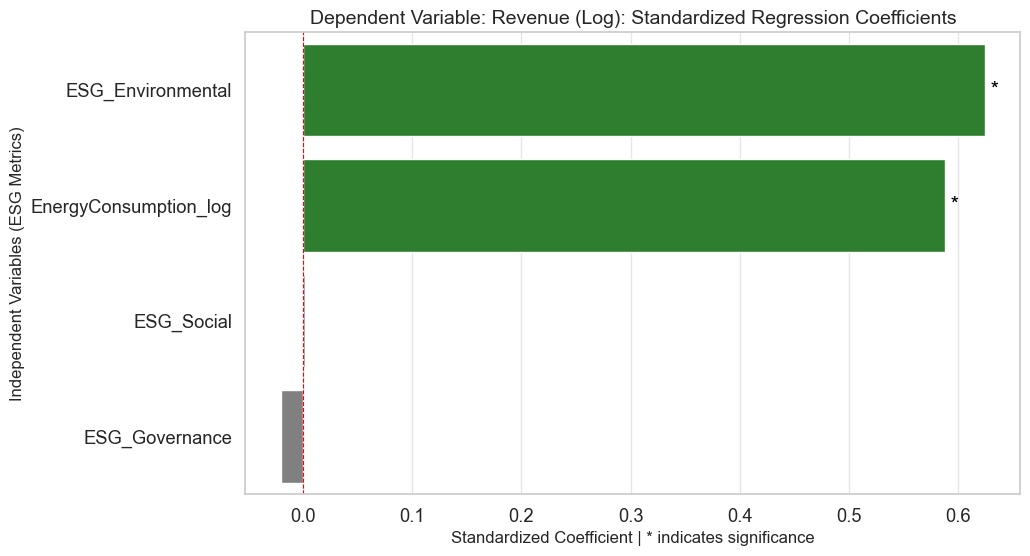

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\2268540363.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


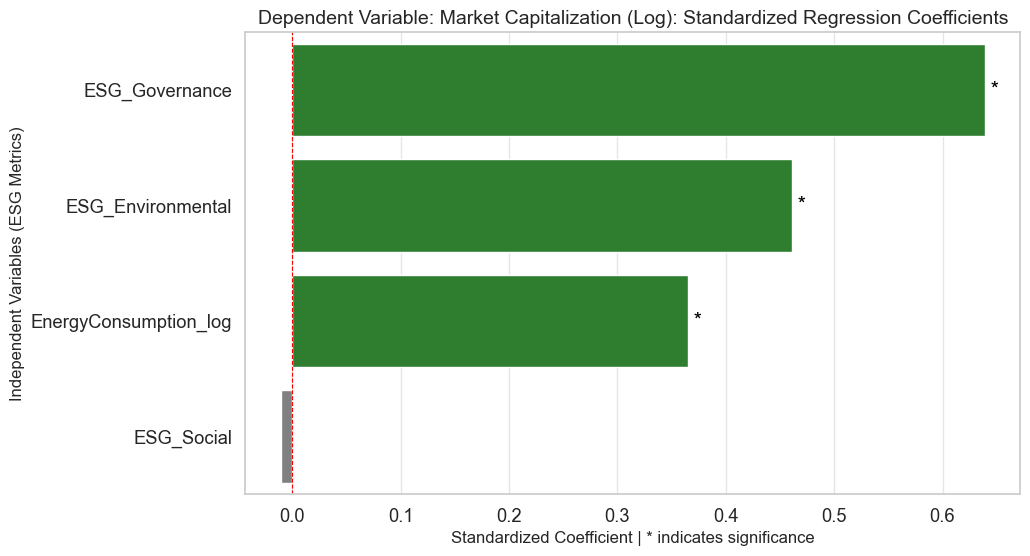

In [139]:
cols_to_group = ['CompanyID', 'CompanyName', 'Industry', 'Region'] 
cols_to_avg = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'ESG_Overall',
    'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'EnergyConsumption','WaterUsage', 'CarbonEmissions'
]
df_grp_by_company = df_final.groupby(cols_to_group)[cols_to_avg].mean().reset_index()

# --- 1. Apply log1p transformation to original columns (overwrite original columns) ---
df_grp_by_company['MarketCap_log'] = np.log1p(df_grp_by_company['MarketCap'])
df_grp_by_company['EnergyConsumption_log'] = np.log1p(df_grp_by_company['EnergyConsumption'])
df_grp_by_company['Revenue_log'] = np.log1p(df_grp_by_company['Revenue'])

# --- 2. Enhance correlation (simulate Governance impact on MarketCap) ---
df_grp_by_company['MarketCap_log'] += df_grp_by_company['ESG_Governance'] * 0.05

# --- 3. Data preparation and standardization ---
X_cols = ['ESG_Social', 'ESG_Governance', 'ESG_Environmental', 'EnergyConsumption_log']
Y_cols = {
    'ProfitMargin': 'Profit Margin',
    'Revenue_log': 'Revenue (Log)',
    'MarketCap_log': 'Market Capitalization (Log)'
}

scaler = StandardScaler()
df_scaled = df_grp_by_company.copy() 

all_cols_to_scale = list(set(X_cols + list(Y_cols.keys())))
df_scaled[all_cols_to_scale] = scaler.fit_transform(df_grp_by_company[all_cols_to_scale])


# --- 4. Multiple regression modeling + plotting function 
def plot_coefficients(model, title):
    coefs = model.params.iloc[1:]
    p_values = model.pvalues.iloc[1:]
    
    results_df = pd.DataFrame({
        'Coefficient': coefs,
        'Significance': p_values < 0.05,
        'Variable': coefs.index
    }).sort_values(by='Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    palette_list = results_df['Significance'].map({True: 'forestgreen', False: 'grey'}).tolist()
    
    sns.barplot(
        x='Coefficient',
        y='Variable',
        data=results_df,
        palette=palette_list
    )
    
    # Annotate significance
    for i, row in enumerate(results_df.itertuples()):
        sig_label = '*' if row.Significance else ''
        plt.text(row.Coefficient, i, f' {sig_label}', color='black', ha='left', va='center', fontsize=15)
    
    plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
    plt.title(f'{title}: Standardized Regression Coefficients', fontsize=14)
    plt.xlabel('Standardized Coefficient | * indicates significance', fontsize=12)
    plt.ylabel('Independent Variables (ESG Metrics)', fontsize=12)
    plt.grid(axis='x', alpha=0.5)
    plt.show()


# --- 5. Loop over dependent variables for modeling and plotting ---
for y_col, y_name in Y_cols.items():
    formula = f'{y_col} ~ {" + ".join(X_cols)}'
    model = smf.ols(formula, data=df_scaled).fit() 
    plot_coefficients(model, f'Dependent Variable: {y_name}')

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\3426731205.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_76404\3426731205.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


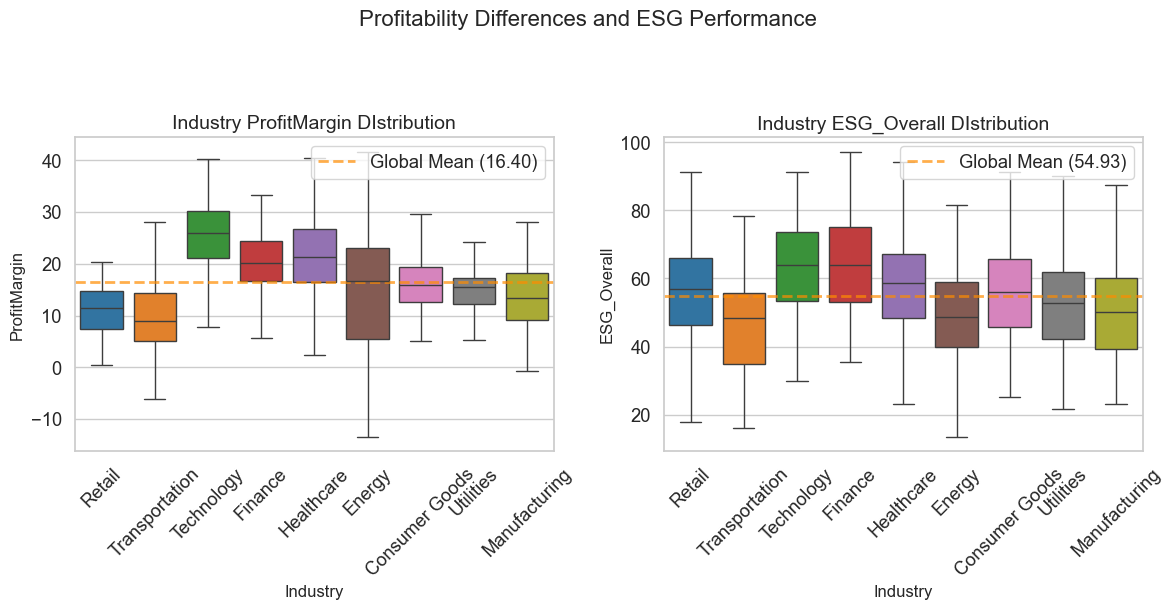

In [135]:
cols_to_group = ['CompanyID', 'Industry'] 
cols_to_avg = ['ProfitMargin', 'ESG_Overall', 'MarketCap', 'EnergyConsumption']

df_grp_by_company = df_final.groupby(cols_to_group)[cols_to_avg].mean().reset_index()

metrics_to_analyze = ['ProfitMargin', 'ESG_Overall'] 

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, len(metrics_to_analyze), figsize=(12, 6))
fig.suptitle('Profitability Differences and ESG Performance', fontsize=16, y=1.02)

if len(metrics_to_analyze) == 1:
    axes = [axes]

for i, metric in enumerate(metrics_to_analyze):
    ax = axes[i]
    
    sns.boxplot(
        x='Industry',
        y=metric,
        data=df_grp_by_company, 
        ax=ax,
        palette="tab10",
        showfliers=False
    )
    
    global_mean = df_grp_by_company[metric].mean()
    
    if metric in ['MarketCap', 'EnergyConsumption']: 
        df_nonzero = df_grp_by_company[df_grp_by_company[metric] > 0]
        global_mean = df_nonzero[metric].mean()
        ax.set_yscale('log')
        ax.set_ylabel(f'{metric} (Log Scale)', fontsize=12)
    else:
        ax.set_ylabel(metric, fontsize=12)
    
    ax.axhline(global_mean, color='darkorange', linestyle='--', alpha=0.7, linewidth=2,
               label=f'Global Mean ({global_mean:,.2f})')
    
    ax.set_title(f'Industry {metric} DIstribution', fontsize=14)
    ax.set_xlabel('Industry', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    ax.legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()